<a href="https://colab.research.google.com/github/Churrascooo/Practica-1/blob/main/SEMANA1/CodigoSemana1_Practica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importación de MIMIC-IV

A continuación se muestran 4 bloques de código que sirven para la importación de la base de datos y las notas de MIMIC-IV dentro de este notebook.
La forma de importación será mediante google drive, ya que MIMIC-IV es una base de datos muy grande y colab no lo soporta.
El formato de importación es en 3 pasos:
1) Importar desde google drive
2) Ubicar el archivo zip dentro del drive
3) Descomprimir el archivo (Este paso se debe ejecutar siempre que se trabaje con este notebook)

In [1]:
#Importar la base de datos de MIMIC-IV
#Se importará desde google drive, ya que la base de datos es muy grande y colab no soporta tanto peso

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Se ubica el archivo zip dentro del drive, con su nombre específico
#Esto sirve una vez, ya que cada vez que se reinicie o se abra este colab, no se debe buscar nuevamente la dirección del archivo

!find /content/drive/MyDrive -maxdepth 3 -type f -name "*.zip"

/content/drive/MyDrive/Lenguanje_C.zip
/content/drive/MyDrive/mimic-iv-3.1.zip
/content/drive/MyDrive/mimic-iv-note-deidentified-free-text-clinical-notes-2.2.zip


In [3]:
#Descomprimir la base de datos de MIMIC-IV (forzando overwrite)
#IMPORTANTE: SE DEBE EJECUTAR ESTE BLOQUE CADA VEZ QUE SE UTILICE ESTE COLAB!

!rm -rf /content/mimiciv
!mkdir -p /content/mimiciv
!unzip -o -q "/content/drive/MyDrive/mimic-iv-3.1.zip" -d /content/mimiciv

In [4]:
#Descomprimir las notas de MIMIC-IV Notes (forzando overwrite)
#IMPORTANTE: ESTE BLOQUE SE DEBE EJECUTAR CADA VEZ QUE SE ABRE ESTE COLAB

!rm -rf /content/mimiciv_notes
!mkdir -p /content/mimiciv_notes
!unzip -o -q "/content/drive/MyDrive/mimic-iv-note-deidentified-free-text-clinical-notes-2.2.zip" -d /content/mimiciv_notes

# Análisis de MIMIC-IV

Se hará un análisis para inspeccionar y entender que hay dentro de la base de datos de MIMIC-IV. Para ello, se usarán funciones de Python para saber que contiene cada módulo (hosp-icu). A su vez, se verán las tablas más importante que tienen, las cuales son:
- **Hosp** -> patients, admissions
- **Icu** -> icustays

In [5]:
#Importación de librerías

import os #Se importa os para interactuar con el sistema operativo y así manejar archivos
import pandas as pd

!pip -q install scikit-survival

import numpy as np
import matplotlib.pyplot as plt

from sksurv.nonparametric import kaplan_meier_estimator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 10.1 MB/s eta 0:00:00


In [6]:
#En este bloque se definen las rutas base del dataset MIMIC-IV, separando los módulos hospitalarios (hosp) y de cuidados intensivos (icu).

MIMIC_ROOT = "/content/mimiciv/mimic-iv-3.1" #Esta es la ruta raíz donde se encuentra mimic-iv ya descomprimido
HOSP_DIR = os.path.join(MIMIC_ROOT, "hosp") #Ruta a hosp
ICU_DIR  = os.path.join(MIMIC_ROOT, "icu") #Ruta a icu

#Función que se encarga de construir la ruta al archivo CSV comprimido
#Se seleccionan solo columnas específicas para optimizar la memoria
def load_hosp(table, usecols=None):
    path = os.path.join(HOSP_DIR, f"{table}.csv.gz")
    return pd.read_csv(path, compression="gzip", usecols=usecols)

#Hace lo mismo que la función anterior pero con icu
def load_icu(table, usecols=None):
    path = os.path.join(ICU_DIR, f"{table}.csv.gz")
    return pd.read_csv(path, compression="gzip", usecols=usecols)

In [7]:
#Se recorren los archivos contenidos en HOSP_DIR, y se ordenan por alfabeto para mayor comprensión.

print("Tablas HOSP:")
for f in sorted(os.listdir(HOSP_DIR)):
    print(" -", f)

Tablas HOSP:
 - admissions.csv.gz
 - d_hcpcs.csv.gz
 - d_icd_diagnoses.csv.gz
 - d_icd_procedures.csv.gz
 - d_labitems.csv.gz
 - diagnoses_icd.csv.gz
 - drgcodes.csv.gz
 - emar.csv.gz
 - emar_detail.csv.gz
 - hcpcsevents.csv.gz
 - labevents.csv.gz
 - microbiologyevents.csv.gz
 - omr.csv.gz
 - patients.csv.gz
 - pharmacy.csv.gz
 - poe.csv.gz
 - poe_detail.csv.gz
 - prescriptions.csv.gz
 - procedures_icd.csv.gz
 - provider.csv.gz
 - services.csv.gz
 - transfers.csv.gz


In [8]:
#Se recorren los archivos contenidos en ICU_DIR, y se ordenan por alfabeto para mayor comprensión.

print("\nTablas ICU:")
for f in sorted(os.listdir(ICU_DIR)):
    print(" -", f)


Tablas ICU:
 - caregiver.csv.gz
 - chartevents.csv.gz
 - d_items.csv.gz
 - datetimeevents.csv.gz
 - icustays.csv.gz
 - ingredientevents.csv.gz
 - inputevents.csv.gz
 - outputevents.csv.gz
 - procedureevents.csv.gz


In [9]:
#Se carga la tabla "patients" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

patients = load_hosp(
    "patients",
    usecols=["subject_id", "gender", "anchor_age", "anchor_year"]
)
patients.head() #Muestra las primeras filas para así tener una idea inicial

,subject_id,gender,anchor_age,anchor_year
0,10000032,F,52,2180
1,10000048,F,23,2126
2,10000058,F,33,2168
3,10000068,F,19,2160
4,10000084,M,72,2160


In [10]:
#Se carga la tabla "admissions" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

admissions = load_hosp(
    "admissions",
    usecols=[
        "subject_id",
        "hadm_id",
        "admittime",
        "dischtime",
        "deathtime",
        "hospital_expire_flag"
    ]
)
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,0


In [11]:
#Se carga la tabla "icustays" que pertenece a icu
#Se seleccionan solo las columnas relevantes para el análisis demográfico

icustays = load_icu(
    "icustays",
    usecols=[
        "subject_id",
        "hadm_id",
        "stay_id",
        "intime",
        "outtime"
    ]
)
icustays.head()

,subject_id,hadm_id,stay_id,intime,outtime
0,10000032,29079034,39553978,2180-07-23 14:00:00,2180-07-23 23:50:47
1,10000690,25860671,37081114,2150-11-02 19:37:00,2150-11-06 17:03:17
2,10000980,26913865,39765666,2189-06-27 08:42:00,2189-06-27 20:38:27
3,10001217,24597018,37067082,2157-11-20 19:18:02,2157-11-21 22:08:00
4,10001217,27703517,34592300,2157-12-19 15:42:24,2157-12-20 14:27:41


In [12]:
#Se muestra información relevante de las tablas patients, admissions e icustays
#La idea de esto es conocer el número de filas y columnas, los tipos de datos, y ver si hay valores nulos en cada variable

patients.info()
print("\n")
admissions.info()
print("\n")
icustays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364627 entries, 0 to 364626
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   subject_id   364627 non-null  int64 
 1   gender       364627 non-null  object
 2   anchor_age   364627 non-null  int64 
 3   anchor_year  364627 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 11.1+ MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   subject_id            546028 non-null  int64 
 1   hadm_id               546028 non-null  int64 
 2   admittime             546028 non-null  object
 3   dischtime             546028 non-null  object
 4   deathtime             11790 non-null   object
 5   hospital_expire_flag  546028 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 25.0+ MB


<class 'pandas

---

Ahora corresponde el análisis para inspeccionar y entender que hay dentro de las notas de MIMIC-IV. Dentro de estas notas se tienen 4 carpetas, las cuales son:
- **discharge** -> resumen del alta de los pacientes
- **radiology** -> texto de informes radiológicos
- **discharge_detail** -> lo mismo que discharge pero normalizado
- **radiology_detail** -> lo mismo que radiology pero normalizado

Se usará **radiology.csv.gz** porque tiene los datos útiles para trabajar, como hadm_id, timestap y muchas radiografías que se hacen en las primeras horas.

In [13]:
#Sirve para ver la estructura real del zip de notes
!find /content/mimiciv_notes -type f

#NOTA: SHA256SUMS y LICENSE son documentos de texto.
#LICENSE contiene la licencia de acceso restringido a los datos
#SHA256SUMS contiene los hashes de archivos y los nombres de los archivos que hay dentro
#Los hashes son un código que garantizan que el contenido de los archivos no haya sido alterado desde que se generaron o se distribuyeron

/content/mimiciv_notes/note/discharge_detail.csv.gz
/content/mimiciv_notes/note/radiology_detail.csv.gz
/content/mimiciv_notes/note/discharge.csv.gz
/content/mimiciv_notes/note/radiology.csv.gz
/content/mimiciv_notes/LICENSE.txt
/content/mimiciv_notes/SHA256SUMS.txt


In [14]:
RAD_FILE = "/content/mimiciv_notes/note/radiology.csv.gz"

#Se carga una muestra pequeña
rad_sample = pd.read_csv(RAD_FILE, nrows=5000)

#Ver los primeros datos
print("Shape (muestra):", rad_sample.shape)
rad_sample.head()

Shape (muestra): (5000, 8)


,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text
0,10000032-RR-14,10000032,22595853.0,RR,14,2180-05-06 21:19:00,2180-05-06 23:32:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
1,10000032-RR-15,10000032,22595853.0,RR,15,2180-05-06 23:00:00,2180-05-06 23:26:00,EXAMINATION: LIVER OR GALLBLADDER US (SINGLE ...
2,10000032-RR-16,10000032,22595853.0,RR,16,2180-05-07 09:55:00,2180-05-07 11:15:00,"INDICATION: ___ HCV cirrhosis c/b ascites, hi..."
3,10000032-RR-18,10000032,NaN,RR,18,2180-06-03 12:46:00,2180-06-03 14:01:00,EXAMINATION: Ultrasound-guided paracentesis.\...
4,10000032-RR-20,10000032,NaN,RR,20,2180-07-08 13:18:00,2180-07-08 14:15:00,EXAMINATION: Paracentesis\n\nINDICATION: ___...


In [15]:
#Ver las columnas de radiology
print(rad_sample.columns)

Index(['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq',
       'charttime', 'storetime', 'text'],
      dtype='object')


In [16]:
#Checkeo rápido para ver los nulos
for c in ["subject_id", "hadm_id", "charttime", "text"]:
    if c in rad_sample.columns:
        print(f"\n{c}:")
        print("  % nulos:", rad_sample[c].isna().mean())


subject_id:
  % nulos: 0.0

hadm_id:
  % nulos: 0.5032

charttime:
  % nulos: 0.0

text:
  % nulos: 0.0


# Filtrado de la población geriátrica


La idea de esta sección es generar la cohorte base, seleccionando a los pacientes de tercera edad, es decir con 60+ años. Todo esto se hará desde los módulos hosp e icu de MIMIC-IV

In [17]:
#Se carga la tabla de patients con la información demográfica básica
patients = load_hosp(
    "patients",
    usecols=["subject_id", "gender", "anchor_age", "anchor_year"]
)

#Se carga la tabla admissions con información de hospitalizaciones
admissions = load_hosp(
    "admissions",
    usecols=["subject_id", "hadm_id", "admittime", "dischtime", "deathtime", "hospital_expire_flag"]
)

#Se carga la tabla icustays con información de estancias en icu
icustays = load_icu(
    "icustays",
    usecols=["subject_id", "hadm_id", "stay_id", "intime", "outtime"]
)

#Muestra el tamaño de cada tabla para así verificar si se cargaron bien los datos
print("patients:", patients.shape)
print("admissions:", admissions.shape)
print("icustays:", icustays.shape)

patients: (364627, 4)
admissions: (546028, 6)
icustays: (94458, 5)


In [18]:
#Convertir las columnas de tiempo en la tabla admissions al formato datetime
for col in ["admittime", "dischtime", "deathtime"]:
    admissions[col] = pd.to_datetime(admissions[col], errors="coerce")

#Convertir las columnas de tiempo en la tabla icustays al formato datetime
for col in ["intime", "outtime"]:
    icustays[col] = pd.to_datetime(icustays[col], errors="coerce")

In [19]:
#Se une admissions con patients, todo esto usando subject_id
#Esto permite tener en una misma tabla los tiempos de hospitalización y las variables para calcular edad
cohort_hosp = admissions.merge(
    patients,
    on="subject_id",
    how="inner",
    validate="many_to_one" #many_to_one garantiza que cada subject_id en patients aparezca como máximo una vez
)                          #Esto es útil ya que en admissions puede aparecer muchas veces (un paciente puede tener varias hospitalizaciones).

cohort_hosp["admit_year"] = cohort_hosp["admittime"].dt.year #Extrae el año de admisión (hospitalización) a partir de admittime
cohort_hosp["age_at_admit"] = cohort_hosp["anchor_age"] + (cohort_hosp["admit_year"] - cohort_hosp["anchor_year"]) #Estima la edad al momento de la admisión
                                                                                                                  #Se ajuste la diferencia de años entre anchor_age y anchor_year
cohort_hosp_60 = cohort_hosp.loc[cohort_hosp["age_at_admit"] >= 60].copy() #Se filtran los pacientes que ingresen y tengan 60+ años

#Se verifican los tamaños antes y después del filtrado
print("Cohorte HOSP total:", cohort_hosp.shape)
print("Cohorte HOSP 60+   :", cohort_hosp_60.shape)

#Muestra las columnas relevantes de la cohorte geriátrica para analizar visualmente
cohort_hosp_60[["subject_id","hadm_id","gender","age_at_admit","admittime","dischtime","hospital_expire_flag"]].head()

Cohorte HOSP total: (546028, 11)
Cohorte HOSP 60+   : (287702, 11)


,subject_id,hadm_id,gender,age_at_admit,admittime,dischtime,hospital_expire_flag
5,10000084,23052089,M,72,2160-11-21 01:56:00,2160-11-25 14:52:00,0
6,10000084,29888819,M,72,2160-12-28 05:11:00,2160-12-28 16:07:00,0
10,10000161,22148160,M,60,2163-08-20 01:42:00,2163-08-20 16:33:00,0
14,10000635,20642640,F,81,2143-12-23 14:55:00,2143-12-24 12:52:00,0
15,10000635,26134563,F,74,2136-06-19 14:24:00,2136-06-20 11:30:00,0


In [20]:
#Se une la cohorte hospitalaria geriátrica (60+) con las estancias en UCI (icustays)
#Esto se hace mediante el subject_id y hadm_id para así asegurar que la UCI corresponda a la misma hospitalización del paciente

cohort_icu_60 = cohort_hosp_60.merge(
    icustays,
    on=["subject_id", "hadm_id"],
    how="inner",
    validate="one_to_many"
)

print("Cohorte HOSP+ICU (60+):", cohort_icu_60.shape)
cohort_icu_60[["subject_id","hadm_id","stay_id","age_at_admit","admittime","intime","outtime"]].head()

Cohorte HOSP+ICU (60+): (62445, 14)


,subject_id,hadm_id,stay_id,age_at_admit,admittime,intime,outtime
0,10000690,25860671,37081114,86,2150-11-02 18:02:00,2150-11-02 19:37:00,2150-11-06 17:03:17
1,10000980,26913865,39765666,76,2189-06-27 07:38:00,2189-06-27 08:42:00,2189-06-27 20:38:27
2,10001843,26133978,39698942,76,2134-12-05 00:10:00,2134-12-05 18:50:03,2134-12-06 14:38:26
3,10001884,26184834,37510196,77,2131-01-07 20:39:00,2131-01-11 04:20:05,2131-01-20 08:27:30
4,10002155,20345487,32358465,83,2131-03-09 20:33:00,2131-03-09 21:33:00,2131-03-10 18:09:21


In [21]:
#Se verifica la edad mínima y máxima de la cohorte hospitalaria geriátrica (60+)
print("Edad mínima (HOSP 60+):", cohort_hosp_60["age_at_admit"].min())
print("Edad máxima (HOSP 60+):", cohort_hosp_60["age_at_admit"].max())

#Se printea el número de hospitalizaciones únicas en la cohorte geriátrica hospitalaria
print("Num hospitalizaciones (hadm_id) en HOSP 60+:", cohort_hosp_60["hadm_id"].nunique())

#Se printea el número de estancias en UCI
print("Num estancias UCI (stay_id) en ICU 60+:", cohort_icu_60["stay_id"].nunique())

#Se printea la mortalidad hospitalaria promedio
print("Mortalidad (hospital_expire_flag) en HOSP 60+:",
      cohort_hosp_60["hospital_expire_flag"].mean())

Edad mínima (HOSP 60+): 60
Edad máxima (HOSP 60+): 106
Num hospitalizaciones (hadm_id) en HOSP 60+: 287702
Num estancias UCI (stay_id) en ICU 60+: 62445
Mortalidad (hospital_expire_flag) en HOSP 60+: 0.03255451821676596


In [22]:
OUT_DIR = "/content/outputs" #Se define el directorio para guardar los resultados
os.makedirs(OUT_DIR, exist_ok=True) #Crea el directorio en caso de que no exista, evitando así errores en caso de repetición

cohort_hosp_60.to_parquet(os.path.join(OUT_DIR, "cohort_hosp_60.parquet"), index=False) #Guarda la cohorte hospitalaria geriátrica en formato Parquet
cohort_icu_60.to_parquet(os.path.join(OUT_DIR, "cohort_icu_60.parquet"), index=False) #Guarda la cohorte geriátrica con estancia en UCI en formato Parquet

print("✅ Guardado en:", OUT_DIR)

#Un archivo Parquet es un formato de almacenamiento de datos de código abierto, orientado a columnas
#La idea de usar este tipo de archivo es porque está diseñado para la eficiencia en grandes volúmenes de datos

✅ Guardado en: /content/outputs


# Integración del historial clínico

En esta sección se cargarán las tablas de diagnósticos clínicos y su diccionario asociado. Esto permitirá la identificación de los antecedentes médicos de cada hospitalización.
A su vez se integrarán los antecedentes médicos a la cohorte geriátrica hospitalaria. Cada hospitalización quedará asociada a sus diagnósticos clínicos, con una descripción del diagnóstico.
Tambipen se cargarán las prescripciones farmacológicas registradas durante las hospitalizaciones.
Por último, se integrarán los medicamentos a la cohorte geriátrica, considerando solo las prescripciones iniciadas dentro de las primeras 24 horas desde la admisión hospitalaria. La idea de esto es representar la exposición farmacológica al ingreso.
Además, se almacenarán los datasets resultantes de diagnósticos y medicamentos en formato Parquet, lo que permite asegurar la reproducibilidad del análisis y no recalcular los datos.

In [23]:
#Se carga la tabla de diagnósticos clínicos asociados a cada hospitalización
diagnoses = load_hosp(
    "diagnoses_icd",
    usecols=["subject_id", "hadm_id", "icd_code", "icd_version"]
)

#Se carga el diccionario de diagnósticos para traducir códigos ICD a descripciones clínicas
icd_dict = load_hosp(
    "d_icd_diagnoses",
    usecols=["icd_code", "icd_version", "long_title"]
)

#Verifica el tamaño de las tablas cargadas
print("diagnoses:", diagnoses.shape)
print("icd_dict :", icd_dict.shape)

diagnoses: (6364488, 4)
icd_dict : (112107, 3)


In [24]:
#Se unen los diagnósticos clínicos a la cohorte hospitalaria geriátrica (60+)
#Luego se realiza la unión por subject_id y hadm_id para así mantener la coherencia
dx_60 = cohort_hosp_60[["subject_id", "hadm_id"]].merge(
    diagnoses,
    on=["subject_id", "hadm_id"],
    how="left",
    validate="one_to_many"
)

#Se agrega la descripción clínica de cada diagnóstico mediante el diccionario ICD
dx_60 = dx_60.merge(
    icd_dict,
    on=["icd_code", "icd_version"],
    how="left",
    validate="many_to_one"
)

#Verifica el tamaño del dataset integrado
print("dx_60:", dx_60.shape)

#Se analiza los primeros datos
dx_60[["hadm_id", "icd_code", "long_title"]].head()

dx_60: (4054046, 5)


,hadm_id,icd_code,long_title
0,23052089,G3183,Neurocognitive disorder with Lewy bodies
1,23052089,F0280,Dementia in other diseases classified elsewher...
2,23052089,R441,Visual hallucinations
3,23052089,R296,Repeated falls
4,23052089,E785,"Hyperlipidemia, unspecified"


In [25]:
#Se carga la tabla de prescripciones farmacológicas
prescriptions = load_hosp(
    "prescriptions",
    usecols=["subject_id", "hadm_id", "drug", "starttime", "stoptime"]
)

#Se convierte las fechas de cuando se empieza y termina de admnistrar los medicamentos a formato datetime
prescriptions["starttime"] = pd.to_datetime(prescriptions["starttime"], errors="coerce")
prescriptions["stoptime"]  = pd.to_datetime(prescriptions["stoptime"], errors="coerce")

#Verifica el tamaño de la tabla cargada
print("prescriptions:", prescriptions.shape)

prescriptions: (20292611, 5)


In [26]:
#Se unen las preinscripciones a la cohorte geriátrica, para así poder obtener el tiempo de admisión
rx_60 = prescriptions.merge(
    cohort_hosp_60[["hadm_id", "admittime"]],
    on="hadm_id",
    how="inner",
    validate="many_to_one"
)

#Filtra los medicamentos donde el inicio ocurrió dentro de las primeras 24 horas desde la admisión
rx_60_ingreso = rx_60.loc[
    (rx_60["starttime"] >= rx_60["admittime"]) &
    (rx_60["starttime"] <= rx_60["admittime"] + pd.Timedelta(hours=24))
].copy()

#Verifica el tamaño del dataset resultante
print("rx_60_ingreso:", rx_60_ingreso.shape)

#Análisis para los primeros datos
rx_60_ingreso[["hadm_id", "drug", "starttime"]].head()

rx_60_ingreso: (5495531, 6)


,hadm_id,drug,starttime
0,23052089,Pramipexole,2160-11-21 05:00:00
1,23052089,Pravastatin,2160-11-21 20:00:00
3,23052089,Senna,2160-11-21 04:00:00
5,23052089,Sodium Chloride 0.9% Flush,2160-11-21 04:00:00
7,23052089,Senna,2160-11-21 04:00:00


In [27]:
#Se guardan los diagnósticos asociados a la cohorte geriátrica
dx_60.to_parquet(
    os.path.join(OUT_DIR, "dx_60.parquet"),
    index=False
)

#Se guardan los medicamentos que se administraron al ingreso de la cohorte geriátrica
rx_60_ingreso.to_parquet(
    os.path.join(OUT_DIR, "rx_60_ingreso.parquet"),
    index=False
)

#Printeo y confirmación para ver el guardado de los archivos
print("✅ Diagnósticos y medicamentos al ingreso guardados en:", OUT_DIR)

✅ Diagnósticos y medicamentos al ingreso guardados en: /content/outputs


# Identificación de comorbilidades predominantes

Esta sección se encarga de ver el top 5 de las comorbilidades más frecuentes en la población de personas con 60+ años. Para ello, lo que se hará es un filtro para usar solo los diagnósticos válidos, así se evitan los datos nulos. Luego de esto, se usará un contador para tener el número de cada enfermedad común, para luego hacer la selección de las 5 comorbilidades más frecuentes y guardarlas para el uso posterior.

In [28]:
#Filtro para quedarse solo con los diagnósticos válidos (evitar datos nulos)
dx_clean = dx_60.dropna(subset=["icd_code", "long_title"]).copy()

#Mostrar los primeros diagnósticos
print("Diagnósticos válidos:", dx_clean.shape)
dx_clean.head()

Diagnósticos válidos: (4053840, 5)


,subject_id,hadm_id,icd_code,icd_version,long_title
0,10000084,23052089,G3183,10.0,Neurocognitive disorder with Lewy bodies
1,10000084,23052089,F0280,10.0,Dementia in other diseases classified elsewher...
2,10000084,23052089,R441,10.0,Visual hallucinations
3,10000084,23052089,R296,10.0,Repeated falls
4,10000084,23052089,E785,10.0,"Hyperlipidemia, unspecified"


In [29]:
#Contador para ver cuantas veces aparece cada diagnóstico dentro de la cohorte geriátrica
dx_counts = (
    dx_clean.groupby(["icd_code", "long_title"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

#Mostrar los primeros diagnósticos
dx_counts.head(10)

,icd_code,long_title,count
2372,4019,Unspecified essential hypertension,70593
7980,E785,"Hyperlipidemia, unspecified",68844
10313,I10,Essential (primary) hypertension,60436
1129,2724,Other and unspecified hyperlipidemia,50942
21774,Z87891,Personal history of nicotine dependence,48864
11689,K219,Gastro-esophageal reflux disease without esoph...,39007
10361,I2510,Atherosclerotic heart disease of native corona...,35820
2515,42731,Atrial fibrillation,33106
3078,53081,Esophageal reflux,31046
2526,4280,"Congestive heart failure, unspecified",31014


In [30]:
#Hacer la selección de las 5 comorbilidades más repetidas
top5_comorbidities = dx_counts.head(5)

top5_comorbidities

,icd_code,long_title,count
2372,4019,Unspecified essential hypertension,70593
7980,E785,"Hyperlipidemia, unspecified",68844
10313,I10,Essential (primary) hypertension,60436
1129,2724,Other and unspecified hyperlipidemia,50942
21774,Z87891,Personal history of nicotine dependence,48864


In [31]:
#Se guardan el top 5 comorbilidades, para luego usarlas
top5_comorbidities.to_parquet(
    os.path.join(OUT_DIR, "top5_comorbidities.parquet"),
    index=False
)

#Printeo de confirmación de guardado
print("✅ Top 5 comorbilidades guardadas")

✅ Top 5 comorbilidades guardadas


# Fusión de Notas Clínicas (Raw Data)

En esta sección se utilizan las notas clínicas en texto libre del módulo MIMIC-IV notes. Para ello, se vinculan las notas radiológicas a cada hospitalización usando hadm_id. Luego, se filtran solo las notas generadas dentro de las primeras 24 horas desde el ingreso hospitalario. Las notas seleccionadas se concatenan en un solo texto por hospitalización. El resultado de todo esto se guarda en formato Parquet para su uso posterior.

In [32]:
#Se usa la cohorte hospitalaria geriátrica que fue previamente hecha
adm_window = cohort_hosp_60[["subject_id", "hadm_id", "admittime"]].copy()

#Se asegura el datetime
adm_window["admittime"] = pd.to_datetime(adm_window["admittime"], errors="coerce")

#Definir la ventana de 0–24 horas
adm_window["t_start"] = adm_window["admittime"]
adm_window["t_end"]   = adm_window["admittime"] + pd.Timedelta(hours=24)

#Mostrar resultados
print("Ventanas hospitalarias:", adm_window.shape)
adm_window.head()

Ventanas hospitalarias: (287702, 5)


,subject_id,hadm_id,admittime,t_start,t_end
5,10000084,23052089,2160-11-21 01:56:00,2160-11-21 01:56:00,2160-11-22 01:56:00
6,10000084,29888819,2160-12-28 05:11:00,2160-12-28 05:11:00,2160-12-29 05:11:00
10,10000161,22148160,2163-08-20 01:42:00,2163-08-20 01:42:00,2163-08-21 01:42:00
14,10000635,20642640,2143-12-23 14:55:00,2143-12-23 14:55:00,2143-12-24 14:55:00
15,10000635,26134563,2136-06-19 14:24:00,2136-06-19 14:24:00,2136-06-20 14:24:00


In [33]:
#Se asigna la ruta a la variable
RAD_PATH = "/content/mimiciv_notes/note/radiology.csv.gz"

#Se lee el csv y se usan las columnas útiles
radiology = pd.read_csv(
    RAD_PATH,
    usecols=["subject_id", "hadm_id", "charttime", "text"]
)

#Convertir el tiempo a datetime
radiology["charttime"] = pd.to_datetime(radiology["charttime"], errors="coerce")

#Mostrar primeros datos
print("Notas radiología:", radiology.shape)
radiology.head()

Notas radiología: (2321355, 4)


,subject_id,hadm_id,charttime,text
0,10000032,22595853.0,2180-05-06 21:19:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
1,10000032,22595853.0,2180-05-06 23:00:00,EXAMINATION: LIVER OR GALLBLADDER US (SINGLE ...
2,10000032,22595853.0,2180-05-07 09:55:00,"INDICATION: ___ HCV cirrhosis c/b ascites, hi..."
3,10000032,NaN,2180-06-03 12:46:00,EXAMINATION: Ultrasound-guided paracentesis.\...
4,10000032,NaN,2180-07-08 13:18:00,EXAMINATION: Paracentesis\n\nINDICATION: ___...


In [34]:
#Fusiona radiology con las columnas útiles de adm_window
rad_merge = radiology.merge(
    adm_window[["hadm_id", "t_start", "t_end"]],
    on="hadm_id",
    how="inner"
)

#Muestra resultados
print("Notas vinculadas a cohort_hosp_60:", rad_merge.shape)

Notas vinculadas a cohort_hosp_60: (709143, 6)


In [35]:
#Filtra rad_merge para obtener las filas donde charttime no es nulo
#Guarda el resultado en 'rad_24h'.
rad_24h = rad_merge.loc[
    (rad_merge["charttime"].notna()) &
    (rad_merge["charttime"] >= rad_merge["t_start"]) & #Busca entrar dentro del rango entre 't_start'
    (rad_merge["charttime"] <= rad_merge["t_end"]) #Busca entrar dentro del rango entre t_end'
].copy()

#Muestra resultados
print("Notas en primeras 24h:", rad_24h.shape)
rad_24h.head()

Notas en primeras 24h: (155801, 6)


,subject_id,hadm_id,charttime,text,t_start,t_end
1,10000764,27897940.0,2132-10-15 09:02:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...,2132-10-14 23:31:00,2132-10-15 23:31:00
13,10000980,20897796.0,2193-08-15 08:52:00,EXAMINATION: BILAT LOWER EXT VEINS\n\nINDICAT...,2193-08-15 01:01:00,2193-08-16 01:01:00
14,10000980,20897796.0,2193-08-15 19:28:00,INDICATION: ___ year old woman with subacute ...,2193-08-15 01:01:00,2193-08-16 01:01:00
17,10001401,21544441.0,2131-06-04 18:31:00,INDICATION: ___ year old woman status post ra...,2131-06-04 00:00:00,2131-06-05 00:00:00
23,10001401,26840593.0,2131-06-19 21:40:00,EXAMINATION: CT abdomen pelvis\n\nINDICATION:...,2131-06-19 21:32:00,2131-06-20 21:32:00


In [36]:
#Se hace un orden temporal
rad_24h = rad_24h.sort_values(["hadm_id", "charttime"])

#Se concatena el texto
notes_24h = (
    rad_24h
    .groupby("hadm_id")["text"]
    .apply(lambda x: "\n\n-----\n\n".join(x.dropna().astype(str)))
    .reset_index(name="notes_first24h")
)

print("Hospitalizaciones con notas 24h:", notes_24h.shape)
notes_24h.head()

Hospitalizaciones con notas 24h: (100423, 2)


,hadm_id,notes_first24h
0,20000034.0,EXAMINATION: RENAL U.S.\n\nINDICATION: ___ y...
1,20000057.0,"CLINICAL HISTORY: Fell on buttocks, chronic l..."
2,20000094.0,EXAMINATION: CHEST (PORTABLE AP)\n\nINDICATIO...
3,20000147.0,INDICATION: ___ year old man s/p Emergent CAB...
4,20000239.0,EXAMINATION: RENAL U.S.\n\nINDICATION: ___ y...


In [37]:
#Verificación para ver si quedó texto vacío
notes_24h["n_chars"] = notes_24h["notes_first24h"].str.len()

notes_24h["n_chars"].describe()
#Con esto se busca confirmar que la fusión produjo texto real

,n_chars
count,100423.000000
mean,1825.998317
std,1837.004408
min,30.000000
25%,592.000000
50%,1156.000000
75%,2423.000000
max,24942.000000


In [38]:
#Guardar para no tener que recalcular todo otra vez
OUT_NOTES = os.path.join(OUT_DIR, "notes_first24h_hosp.parquet")

notes_24h.to_parquet(OUT_NOTES, index=False)

print("✅ Notas clínicas primeras 24h guardadas en:", OUT_NOTES)

✅ Notas clínicas primeras 24h guardadas en: /content/outputs/notes_first24h_hosp.parquet


# Modelado de Supervivencia (Kaplan-Meier)

Para esta sección se construyó un dataset con el tiempo hasta muerte o alta hospitalaria y el indicador de evento.
A su vez, se definió la mortalidad intrahospitalaria como evento y la duración desde el ingreso como tiempo de seguimiento.
Se dividieron las hospitalizaciones en 2 grupos, uno con comorbilidad y otro sin, permitiendo comparar la supervivencia entre ambos
Para cada comorbilidad se estimaron curvas de supervivencia Kaplan-Meier.
Además, se visualizaron curvas de riesgo acumulado para comparar el impacto de las comorbilidades en la mortalidad.

In [39]:
#Se crea el dataset base de supervivencia con las columnas necesarias
surv = cohort_hosp_60[
    ["hadm_id", "admittime", "dischtime", "deathtime", "hospital_expire_flag"]
].copy()  # copy() evita modificar la cohorte original

#Se asegura el formato datetime para los cálculos
for c in ["admittime", "dischtime", "deathtime"]:
    surv[c] = pd.to_datetime(surv[c], errors="coerce")

#Se define el evento, la muerte intrahospitalaria (1 = murió, 0 = censurado)
surv["event"] = surv["hospital_expire_flag"].fillna(0).astype(int)

#Se define el tiempo final, muerte si ocurrió, si no, alta hospitalaria
surv["endtime"] = surv["deathtime"].where(
    surv["event"] == 1,
    surv["dischtime"]
)

#Tiempo hasta evento o censura en días
surv["time_days"] = (
    surv["endtime"] - surv["admittime"]
).dt.total_seconds() / (3600 * 24)

#Se eliminan los casos inválidos (tiempos negativos o nulos)
surv = surv[
    surv["time_days"].notna() & (surv["time_days"] >= 0)
].copy()

#Verificación básica del dataset de supervivencia
print("surv:", surv.shape)
surv[["event", "time_days"]].describe()

surv: (287655, 8)


,event,time_days
count,287655.000000,287655.000000
mean,0.032473,5.307623
std,0.177253,7.282014
min,0.000000,0.000000
25%,0.000000,1.547917
50%,0.000000,3.272222
75%,0.000000,6.356250
max,1.000000,295.988194


In [40]:
#Se carga el archivo con las 5 comorbilidades más frecuentes
top5 = pd.read_parquet(os.path.join(OUT_DIR, "top5_comorbidities.parquet"))

#Se aseguran que los códigos ICD sean string
top5["icd_code"] = top5["icd_code"].astype(str)

#Sd crea una lista con los códigos ICD del Top 5
top5_codes = top5["icd_code"].tolist()
print("Top5 icd_code:", top5_codes)

#Se hace una copia de diagnósticos limpios para evitar modificar el original
dx_tmp = dx_clean.copy()
dx_tmp["icd_code"] = dx_tmp["icd_code"].astype(str)

#Se identifica presencia (mediante un 1) de cada comorbilidad por hospitalización
dx_top5_presence = (
    dx_tmp[dx_tmp["icd_code"].isin(top5_codes)][["hadm_id", "icd_code"]]
    .drop_duplicates()      # evita contar una comorbilidad más de una vez
    .assign(value=1)
)

#Se convierte a formato ancho, o sea una columna por comorbilidad
flags_top5 = (
    dx_top5_presence
    .pivot_table(
        index="hadm_id",
        columns="icd_code",
        values="value",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

#Resultados
print("flags_top5:", flags_top5.shape)
flags_top5.head()

Top5 icd_code: ['4019', 'E785', 'I10', '2724', 'Z87891']
flags_top5: (202901, 6)


icd_code,hadm_id,2724,4019,E785,I10,Z87891
0,20000019,1,1,0,0,0
1,20000024,0,0,0,1,0
2,20000034,0,0,0,0,1
3,20000041,1,1,0,0,0
4,20000057,0,1,0,0,0


In [41]:
#Se une el dataset de supervivencia con las comorbilidades
km_df = surv.merge(
    flags_top5,
    on="hadm_id",
    how="left"
)

#Se rellenan valores faltantes como 0 (no presenta la comorbilidad)
for code in top5_codes:
    if code not in km_df.columns:
        km_df[code] = 0
    km_df[code] = km_df[code].fillna(0).astype(int)

#Resultados del dataset final
print("km_df:", km_df.shape)
km_df[["hadm_id", "event", "time_days"] + top5_codes].head()

km_df: (287655, 13)


,hadm_id,event,time_days,4019,E785,I10,2724,Z87891
0,23052089,0,4.538889,0,1,0,0,0
1,29888819,0,0.455556,0,1,0,0,0
2,22148160,0,0.618750,0,0,0,0,0
3,20642640,0,0.914583,0,0,1,0,0
4,26134563,0,0.879167,1,0,0,0,0


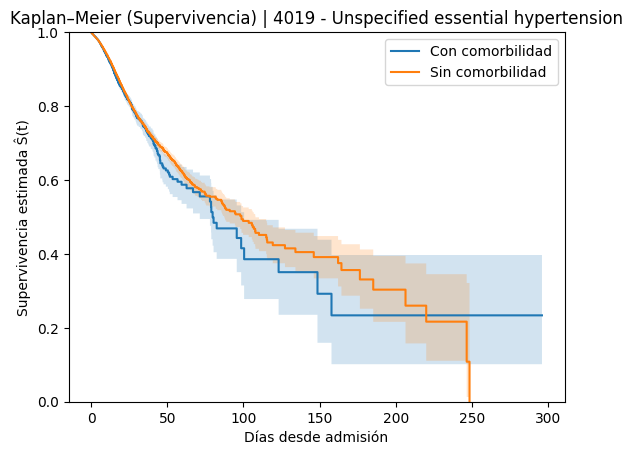

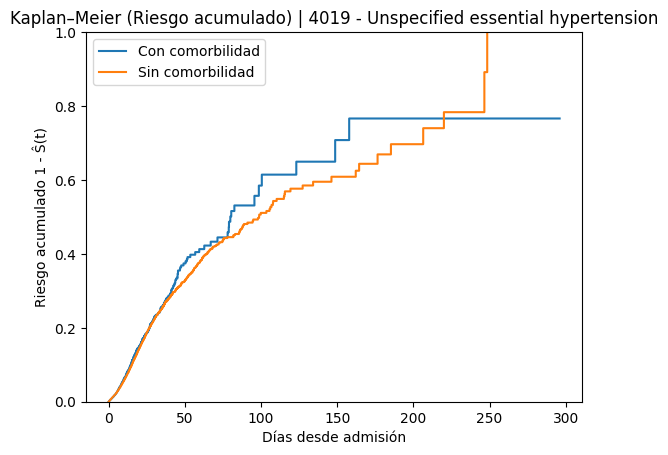

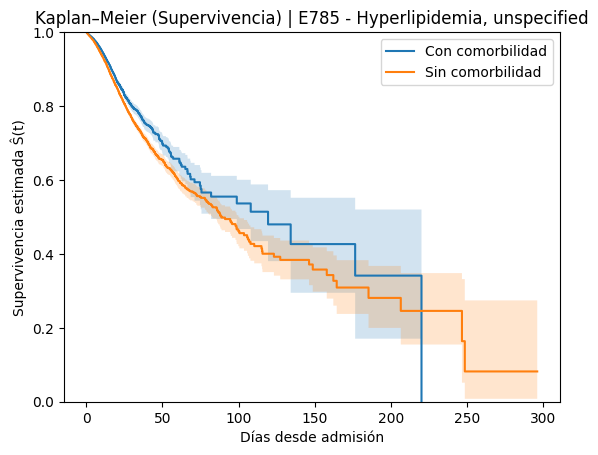

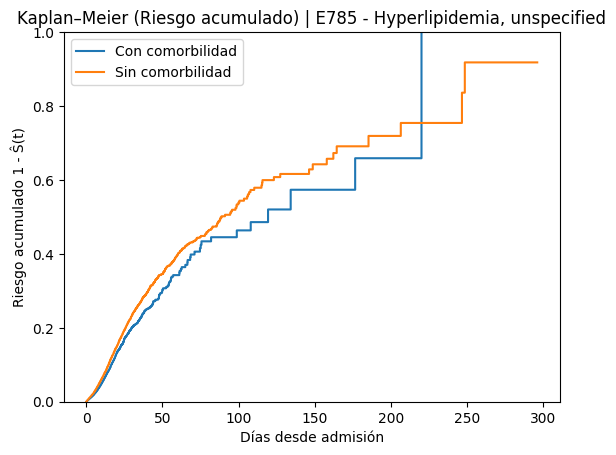

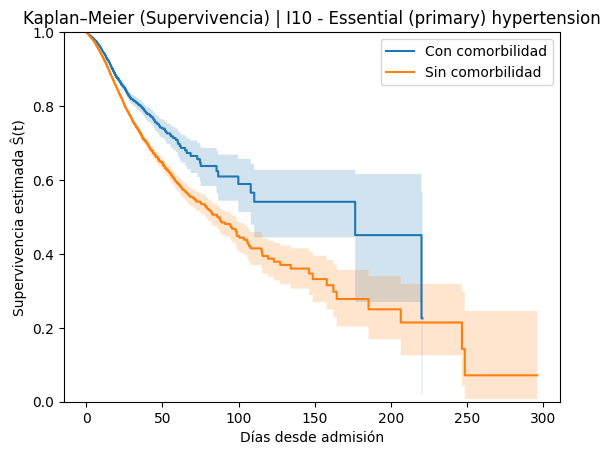

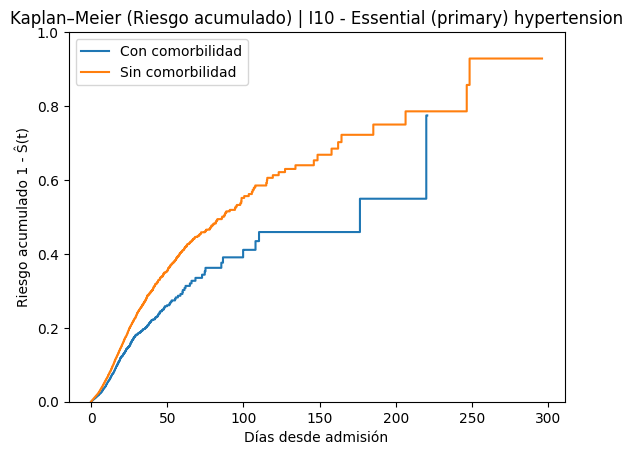

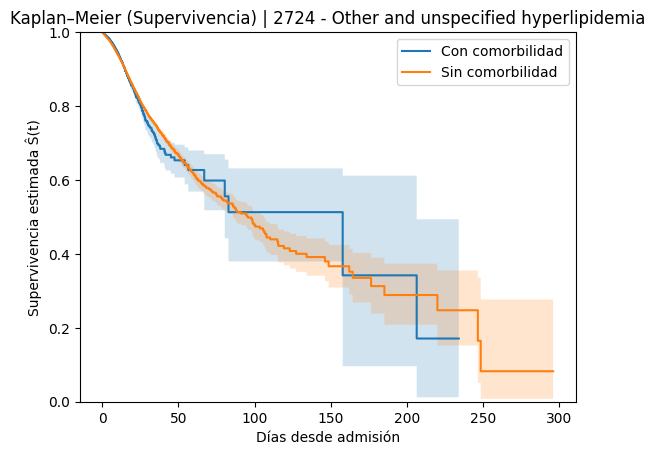

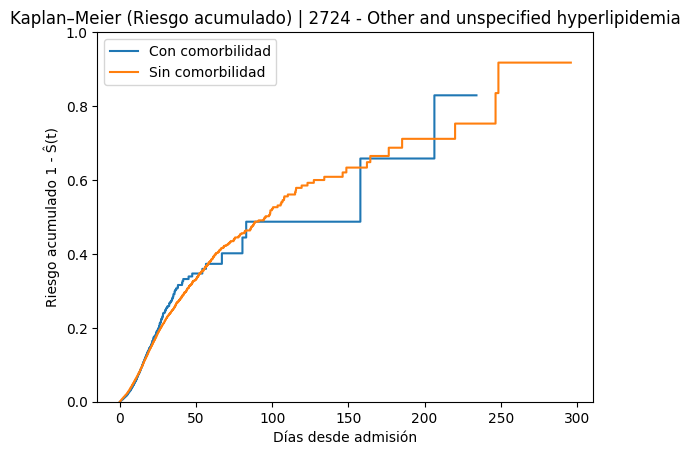

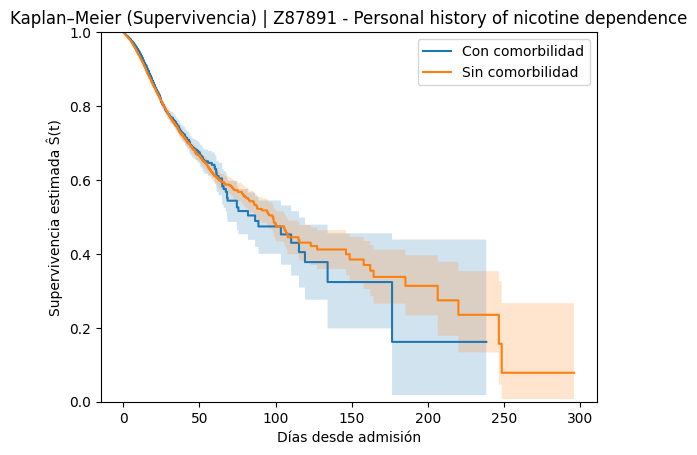

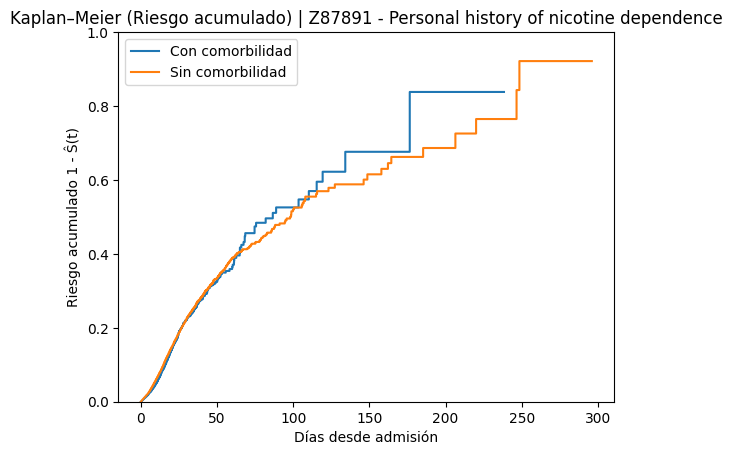

In [42]:
#Diccionario para mapear código ICD a nombre clínico
code_to_title = top5.set_index("icd_code")["long_title"].to_dict()

#Se genera una curva tipo Kaplan–Meier por cada comorbilidad del top 5
for code in top5_codes:

    #Grupo con y sin la comorbilidad
    g1 = km_df[km_df[code] == 1]
    g0 = km_df[km_df[code] == 0]

    #En caso que uno de los grupos esté vacío, se omite
    if len(g1) == 0 or len(g0) == 0:
        print(f"Saltado {code}: un grupo vacío (con={len(g1)}, sin={len(g0)})")
        continue

    #Estimación Kaplan–Meier con intervalos de confianza
    t1, s1, ci1 = kaplan_meier_estimator(
        g1["event"].astype(bool),
        g1["time_days"],
        conf_type="log-log"
    )

    t0, s0, ci0 = kaplan_meier_estimator(
        g0["event"].astype(bool),
        g0["time_days"],
        conf_type="log-log"
    )

    #Título del gráfico
    title = f"{code} - {code_to_title.get(code, '')}"

    # --- Curva de supervivencia ---
    plt.figure()
    plt.step(t1, s1, where="post", label="Con comorbilidad")
    plt.step(t0, s0, where="post", label="Sin comorbilidad")
    plt.fill_between(t1, ci1[0], ci1[1], alpha=0.2, step="post")
    plt.fill_between(t0, ci0[0], ci0[1], alpha=0.2, step="post")
    plt.ylim(0, 1)
    plt.xlabel("Días desde admisión")
    plt.ylabel("Supervivencia estimada Ŝ(t)")
    plt.title(f"Kaplan–Meier (Supervivencia) | {title}")
    plt.legend()
    plt.show()

    # --- Riesgo acumulado ---
    plt.figure()
    plt.step(t1, 1 - s1, where="post", label="Con comorbilidad")
    plt.step(t0, 1 - s0, where="post", label="Sin comorbilidad")
    plt.ylim(0, 1)
    plt.xlabel("Días desde admisión")
    plt.ylabel("Riesgo acumulado 1 - Ŝ(t)")
    plt.title(f"Kaplan–Meier (Riesgo acumulado) | {title}")
    plt.legend()
    plt.show()